              Kirchoff Calculator.            


Enter reference enthalpy value H1 KJ/mol  at T1:  -67
Enter Temperature1 value in K:  78
Enter your delta Cp in J/mol*K:  0.11


Reference enthalpy (H1): -67.0 KJ/mol
Delta Cp: 0.11 J/mol*K     ( 0.00011 KJ/mol*K)
------------------------------------------------------------
             Temperature(K)          |           delta H(T) in KJ/mol.         |          Enthalpy shift from T1.         
          300 K         |              -66.98            |              0.02   KJ/mol          
          400 K         |              -66.96            |              0.04   KJ/mol          
          500 K         |              -66.95            |              0.05   KJ/mol          
          600 K         |              -66.94            |              0.06   KJ/mol          


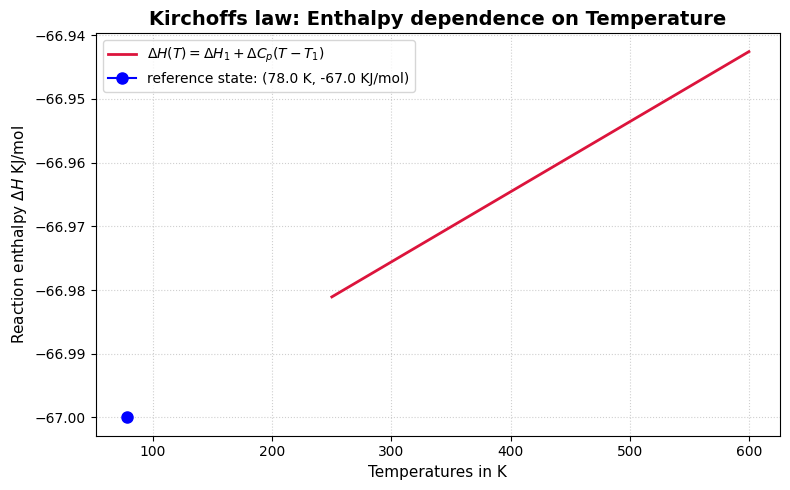

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
print('='*60)
print('              Kirchoff Calculator.            ')
print('='*60)
#stage 1: Get inputs
#input of reference enthalpy H1
try:
	 delta_H1_input = input('Enter reference enthalpy value H1 KJ/mol  at T1: ')
	 if not delta_H1_input.strip():
	 	delta_H1 = -92.22
	 else:
	 	delta_H1 = float(delta_H1_input)
except Exception:
	delta_H1 = -92.22
#input of T1
try:
	T1_input = input('Enter Temperature1 value in K: ')
	if not T1_input.strip():
		T1 = 298.15
	else:
		T1 = float(T1_input)
except Exception:
	T1 = 298.15
#input of delta Cp
try:
	delta_Cp_input = input('Enter your delta Cp in J/mol*K: ')
	if not delta_Cp_input.strip():
		delta_Cp_J = -45.46
	else:
		delta_Cp_J = float(delta_Cp_input)
except Exception:
	delta_Cp_J = -45.46
#convert delta Cp J to KJ
delta_Cp_KJ = delta_Cp_J/1000
	
print(f'Reference enthalpy (H1): {delta_H1} KJ/mol')
print(
    f'Delta Cp: {delta_Cp_J} J/mol*K     ({delta_Cp_KJ: .5f} KJ/mol*K)'
    )

print('-'*60)
#stage 2: temperature points
temperatures = list(range(250, 605, 10))
delta_H_values = []
#stage 3: Using kirchoff equation
for T in temperatures:
	dH_T = delta_H1 + delta_Cp_KJ * (T - T1)
	delta_H_values.append(dH_T)

#stage 4: printed table for selected temperatures
test_temps = [300, 400, 500, 600]
print('             Temperature(K)          |           delta H(T) in KJ/mol.         |          Enthalpy shift from T1.         ')
for T_test in test_temps:
	dH_test = delta_H1 + delta_Cp_KJ * (T_test -T1)
	shift = dH_test - delta_H1
	print(f'          {T_test} K         |          {dH_test: 10.2f}            |          {shift: 8.2f}   KJ/mol          ')
	
#stage 5: plots
plt.figure(figsize=(8,5))
#plot enthalpy vs temperature
plt.plot(
      temperatures,
      delta_H_values,
      color='crimson',
      linewidth=2,
      label=r'$\Delta H(T) = \Delta H_1 + \Delta C_p(T - T_1)$',
      )
#reference temperature as marker
plt.plot(
      T1,
      delta_H1,
      marker='o',
      color='blue',
      markersize=8,
      label=f'reference state: ({T1} K, {delta_H1} KJ/mol)',
      )
plt.title(
      'Kirchoffs law: Enthalpy dependence on Temperature', 
      fontsize=14, 
      fontweight='bold',
      )
plt.xlabel('Temperatures in K', fontsize=11)
plt.ylabel(r'Reaction enthalpy $\Delta H$ KJ/mol', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()